<a href="https://colab.research.google.com/github/gustavocostamiguel/Python_IA/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Sempre ir em executar  tudo
# Importa a biblioteca pandas para manipulação de dados em DataFrames.
import pandas as pd
# Importa a biblioteca numpy para operações numéricas, especialmente com arrays.
import numpy as np
# Importa train_test_split para dividir os dados em conjuntos de treino e teste.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
# Importa GaussianNB, o classificador Naive Bayes Gaussiano.

# Importa LabelEncoder para codificar rótulos categóricos em numéricos.
from sklearn.preprocessing import LabelEncoder
# Importa métricas de avaliação do modelo, como acurácia, precisão, recall, f1-score e relatório de classificação.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
# Importa ConfusionMatrix para visualização da matriz de confusão.
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [2]:
base = pd.read_csv("insurance.csv",keep_default_na=False)
# Exibe as primeiras 5 linhas do DataFrame para uma visualização inicial dos dados.
base.head()

,Unnamed: 0,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,1,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,2,False,Senior,Prole,Cautious,Current,None,Football,None,Economy,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,3,False,Senior,UpperMiddle,Psychopath,Current,None,Football,None,FamilySedan,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,4,False,Adolescent,Middle,Normal,Older,None,EggShell,None,Economy,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,5,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [3]:
# Remove a coluna 'Unnamed: 0' do DataFrame 'base', pois geralmente é um índice extra indesejado do CSV.
base = base.drop(columns=['Unnamed: 0'])
# Exibe as primeiras 5 linhas do DataFrame novamente para verificar se a coluna foi removida com sucesso.
base.head()

,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,Poor,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,False,Senior,Prole,Cautious,Current,None,Football,None,Economy,Normal,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,False,Senior,UpperMiddle,Psychopath,Current,None,Football,None,FamilySedan,Excellent,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,False,Adolescent,Middle,Normal,Older,None,EggShell,None,Economy,Normal,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,Poor,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many


In [4]:
# Seleciona a 8ª coluna (índice 7) do DataFrame 'base' como a variável alvo (y) e converte para array numpy.
y = base.iloc[:,7].values
# Remove a 8ª coluna (índice 7) do DataFrame 'base' e seleciona as colunas restantes como as variáveis preditoras (x), convertendo para array numpy.
X = base.drop(base.columns[7], axis=1).values
# Exibe as primeiras linhas do array 'x' para verificar os dados das variáveis preditoras.
X

array([[False, 'Adult', 'Prole', ..., False, 'Thousand', 'Many'],
       [False, 'Senior', 'Prole', ..., True, 'Thousand', 'Zero'],
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'One'],
       ...,
       [False, 'Senior', 'UpperMiddle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero'],
       [False, 'Adult', 'Middle', ..., True, 'Thousand', 'Zero']],
      dtype=object)

In [5]:
# Inicializa o LabelEncoder, que será usado para converter rótulos categóricos em números.
labelencoder = LabelEncoder()
# Itera sobre todas as colunas do DataFrame 'X'.
for i in range(X.shape[1]):
  # Verifica se o tipo de dado da coluna atual é 'object' (indicando uma coluna categórica).
  if X[:,i].dtype == "object":
     # Aplica o LabelEncoder para transformar os valores categóricos em números inteiros.
     X[:,i] = labelencoder.fit_transform(X[:,i])

In [6]:
# Divide os dados em conjuntos de treinamento e teste.
# X_treinamento e Y_treinamento serão usados para treinar o modelo.
# X_teste e Y_teste serão usados para avaliar o desempenho do modelo.
# test_size=0.3 indica que 30% dos dados serão usados para teste e 70% para treinamento.
# random_state=0 garante que a divisão seja a mesma cada vez que o código for executado, para reprodutibilidade.
X_treinamento, X_teste, Y_treinamento, Y_teste = train_test_split(X, y, test_size=0.3, random_state=0)

In [7]:
modelo = RandomForestClassifier(random_state=1,max_depth=20,max_leaf_nodes=12,n_estimators=500)
modelo.fit(X_treinamento, Y_treinamento)

RandomForestClassifier(max_depth=20, max_leaf_nodes=12, n_estimators=500,
                       random_state=1)

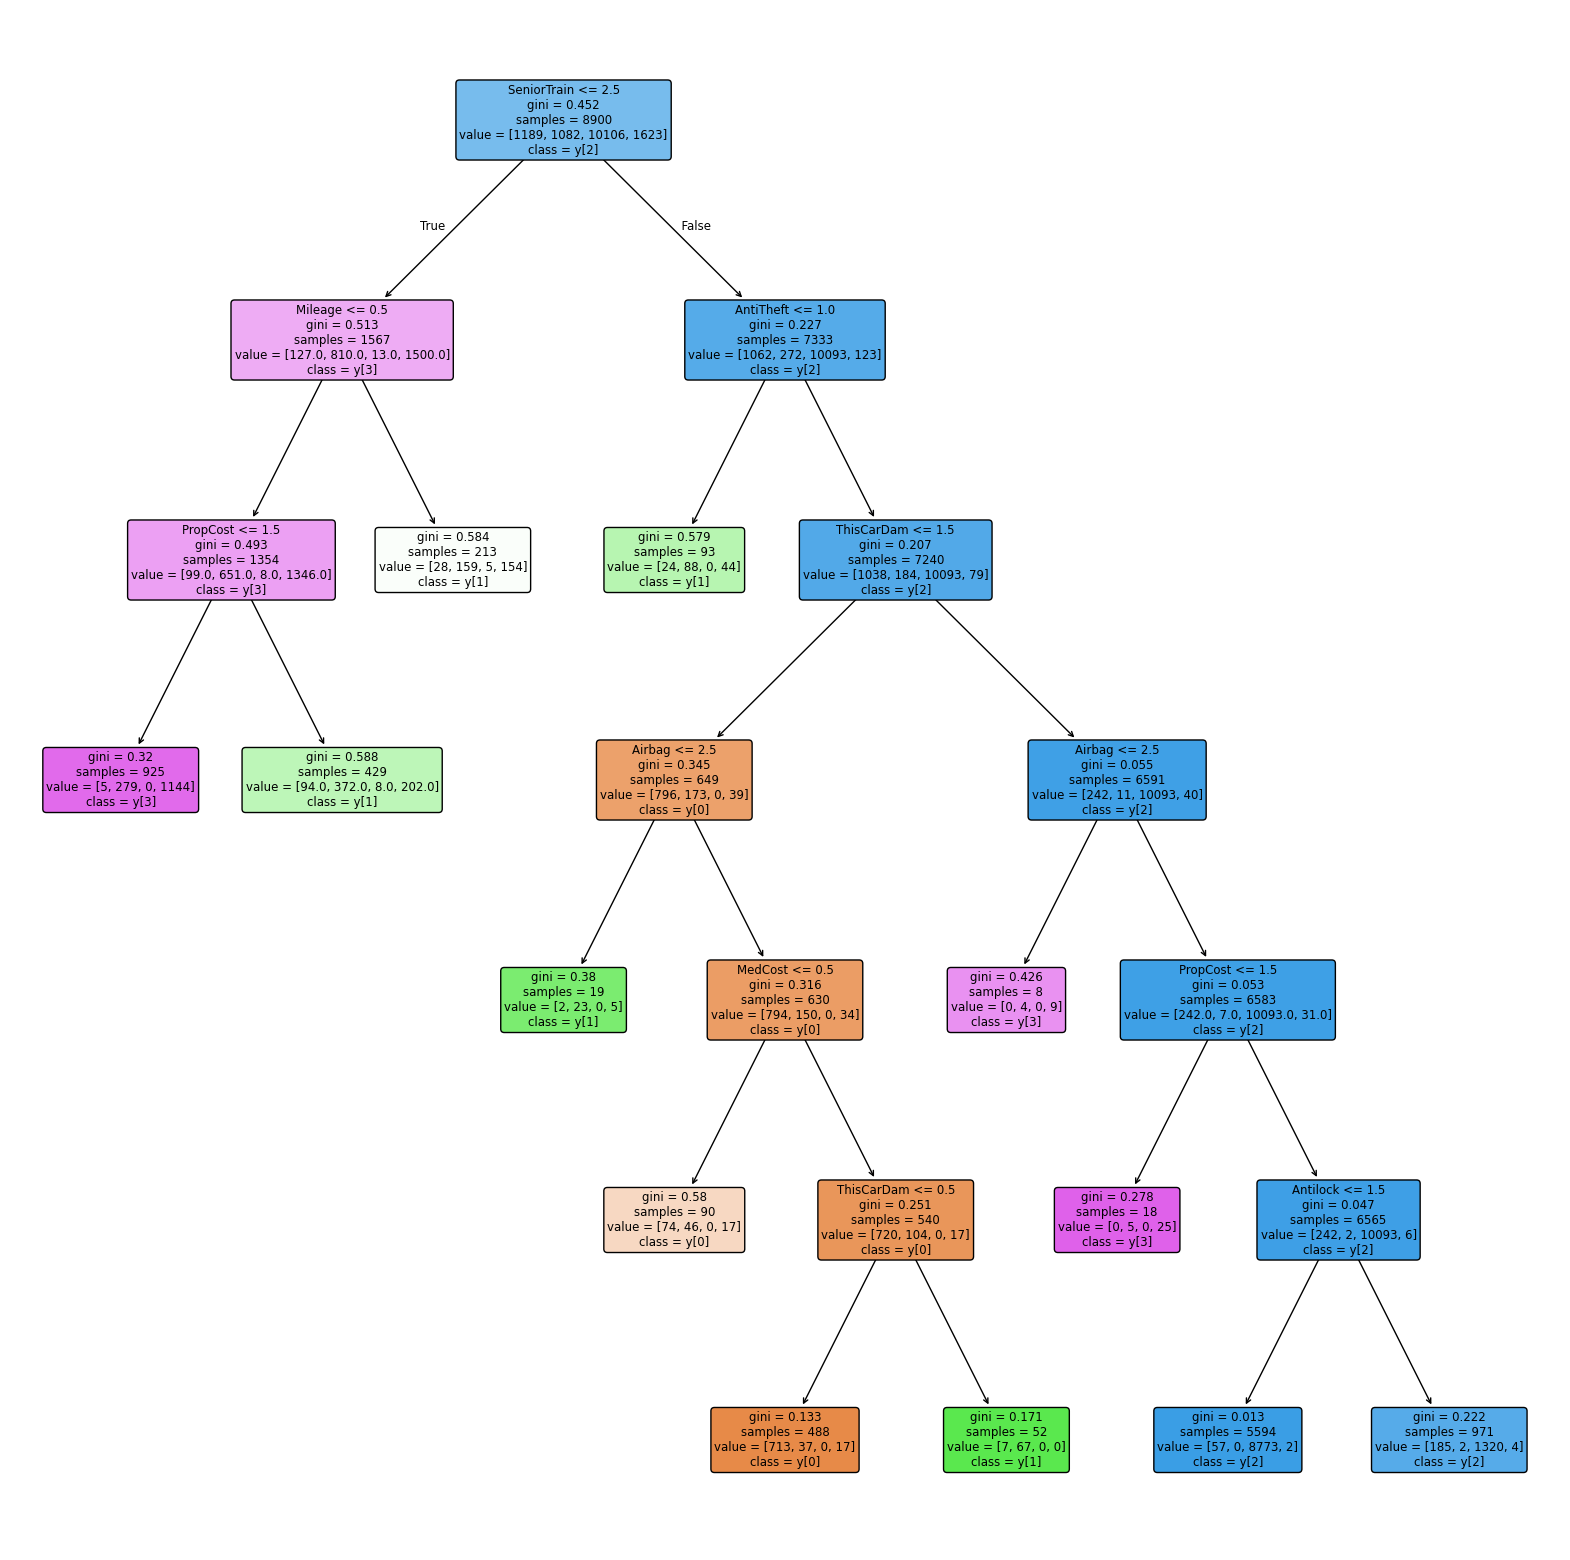

In [8]:
tree_index = 0
tree_to_visualize = modelo.estimators_[tree_index]
plt.figure(figsize=(20,20))
plot_tree(tree_to_visualize, filled=True, feature_names=base.columns[:-1], class_names= True, rounded=True)
plt.show()

In [9]:
previsoes = modelo.predict(X_teste)

In [10]:
previsoes

array(['Severe', 'None', 'None', ..., 'Moderate', 'None', 'None'],
      dtype=object)

In [13]:
# Calcula a acurácia do modelo: proporção de previsões corretas sobre o total de previsões.
accuracy = accuracy_score(Y_teste, previsoes)

# Calcula a precisão do modelo (weighted average): a capacidade do modelo de não rotular como positiva uma amostra que é negativa.
# average='weighted': calcula a média de cada métrica ponderada pelo suporte (número de instâncias verdadeiras) para cada rótulo.
# zero_division=0: Se não houver amostras para uma classe, a métrica será 0 em vez de levantar um erro.
precision = precision_score(Y_teste, previsoes, average='weighted')

# Calcula o recall do modelo (weighted average): a capacidade do modelo de encontrar todas as amostras positivas.
recall = recall_score(Y_teste, previsoes, average='weighted')

# Calcula o F1-score do modelo (weighted average): média harmônica entre precisão e recall.
f1 = f1_score(Y_teste, previsoes, average='weighted')

# Imprime os valores calculados das métricas de avaliação.
print(f'Acurácia: {accuracy}, Precisão: {precision}, Recall: {recall}, F1-Score: {f1}')

Acurácia: 0.937, Precisão: 0.9350901238170333, Recall: 0.937, F1-Score: 0.9336490226066068


In [14]:
report = classification_report(Y_teste, previsoes)
print(report)


              precision    recall  f1-score   support

        Mild       0.90      0.64      0.75       553
    Moderate       0.77      0.73      0.75       473
        None       0.97      1.00      0.98      4294
      Severe       0.88      0.93      0.90       680

    accuracy                           0.94      6000
   macro avg       0.88      0.82      0.85      6000
weighted avg       0.94      0.94      0.93      6000

